# Deep RNN (Recurrent Neural Network)

## 1. Motivation
- In a simple **Neural Network (NN)**, we can improve performance by:
  - Increasing number of neurons in hidden layers,  
  - Adding more hidden layers.  
- This increases the **representation power** of the network, allowing it to capture more complex patterns (e.g., spiral dataset).

The same idea applies to **RNNs**.  
When we stack multiple RNN layers on top of each other → we get a **Deep RNN**.

---

## 2. Normal RNN Recap
- Inputs: sequence of words (e.g., 5-word review for sentiment analysis).  
- At each time step *t*:  
  - Input word $x_t$,  
  - Previous hidden state $h_{t-1}$,  
  - Produce current hidden state $h_t$ and possibly output $y_t$.  

**Unfolded View:**  
For a sequence of length 5 → RNN unrolls into 5 blocks (one per time step).  
Each block passes hidden state to the next.

---

## 3. Limitation of Shallow RNN
- A single-layer RNN may fail to capture complex dependencies → leading to poor accuracy.  

---

## 4. Deep RNN Idea
- Instead of one hidden RNN layer, **stack multiple RNN layers vertically**:
  - **Hidden Layer 1:** Receives direct input $x_t$.  
  - **Hidden Layer 2:** Receives input from Hidden Layer 1 ($h^{(1)}_t$).  
  - **Hidden Layer 3:** Can be added on top, receiving from Layer 2, and so on.  

**Information Flow:**  
- Time flow (horizontal): hidden state passed from $h_{t-1}$ to $h_t$.  
- Depth flow (vertical): output of one RNN layer becomes input to the next layer at the same time step.

---

## 5. Architecture Summary
- Input Layer → Hidden RNN Layer 1 → Hidden RNN Layer 2 → … → Output Layer.  
- On **unfolding in time**, each hidden layer also gets replicated across all time steps.  
- No limit on number of stacked layers (practical limit depends on training stability and compute).

---

## 6. Key Insight
- **Shallow RNN:** captures short/medium dependencies.  
- **Deep RNN:** with stacked layers, captures hierarchical and more complex sequence patterns.  
- Concept is the same as deep feedforward networks but applied in temporal (sequential) setting.

---


# Deep RNN Architecture (with Example)

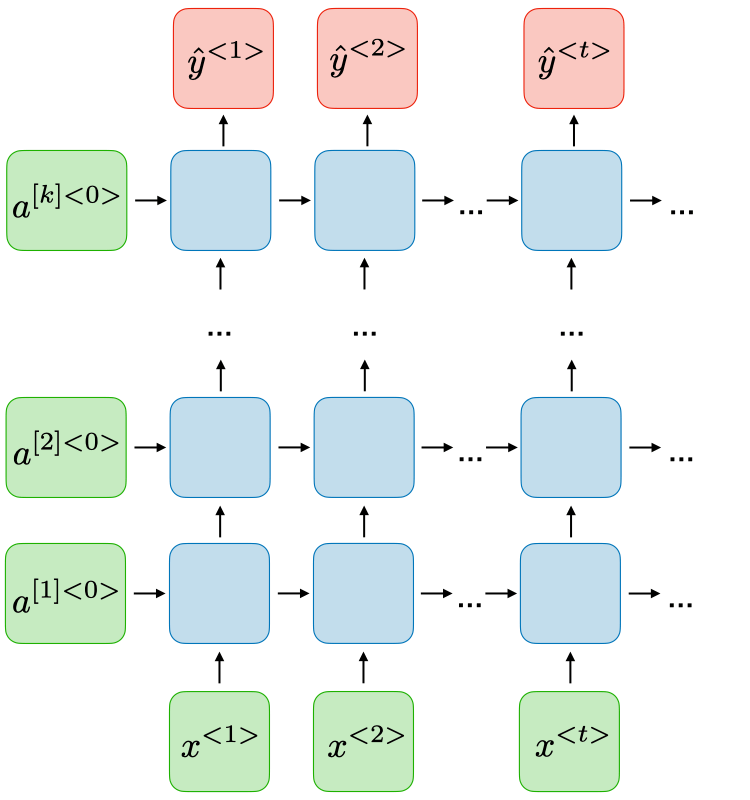
## 1. Problem Setup
- **Task:** Sentiment Analysis (binary classification: Positive = 1, Negative = 0).  
- **Example Reviews:** Each review has 3 words.  
- **Encoding:** Each word represented using one-hot encoding (3-dimensional vector).  
  - Example: `cat → [1,0,0]`, `mat → [0,1,0]`, `rat → [0,0,1]`.

---

## 2. Simple RNN Flow
- Input: sequence of 3 words → 3 time steps.  
- At each time step:
  - Input word vector ($x_t$) enters RNN cell.  
  - Previous hidden state ($h_{t-1}$) also enters via **feedback loop**.  
  - Cell computes hidden state ($h_t$).  
- After last time step ($t=3$), hidden state passes to **sigmoid layer** for final prediction $\hat{y} \in \{0,1\}$.

**Key Point:** RNN cell has internal feedback (state), allowing temporal dependency modeling.  
E.g., with 3 hidden neurons, each step involves a $3 \times 3$ recurrent connection.

---

## 3. Step-by-Step (Unfolded RNN)
- **Time Step 1:** Input $x_1 = [1,0,0]$ (word: *cat*). Initial hidden state = zeros. Output $h_1$ generated.  
- **Time Step 2:** Input $x_2 = [0,1,0]$ (*mat*). Uses $h_1$ and $x_2$ to compute $h_2$.  
- **Time Step 3:** Input $x_3 = [0,0,1]$ (*rat*). Uses $h_2$ and $x_3$ to compute $h_3$.  
- Final $h_3$ → passes to sigmoid → gives $\hat{y}$ (sentiment).  

This shows how **information flows forward in time**.

---

## 4. Deep RNN Idea
- A single RNN layer may not capture complex patterns.  
- **Solution:** Stack multiple RNN layers vertically.  
  - Hidden Layer 1 (e.g., 3 neurons): takes direct word input.  
  - Hidden Layer 2 (e.g., 2 neurons): takes input from Hidden Layer 1.  
  - Final output computed after Layer 2 (via sigmoid).  

---

## 5. Deep RNN Flow (Unfolded)
- Each time step now has **two RNN cells (layer 1 and layer 2)**:
  - Layer 1 → processes input word + previous state.  
  - Layer 2 → processes output of Layer 1 + its own previous state.  
- Across 3 time steps, both layers unfold in parallel.  
- After the last step, Layer 2 passes output to sigmoid → final $\hat{y}$.

---

## 6. Architecture Highlights
- **Horizontal Flow (time):** states pass from $h_{t-1}$ to $h_t$.  
- **Vertical Flow (depth):** states pass from lower hidden layer to upper hidden layer.  
- **Connections:**  
  - Layer 1 → $3 \times 3$ recurrent connections.  
  - Layer 2 → $3 \times 2$ input connection from Layer 1 + $2 \times 2$ recurrent connection.  
- Final output → binary classification.

---

## 7. Key Insight
- **Shallow RNN:** Can capture basic sequential patterns.  
- **Deep RNN:** With stacked layers, can capture **hierarchical and complex temporal dependencies**.  
- This is the same intuition as “deep” feedforward networks, but extended to sequential data.


# Deep RNN — Notation and Equations

## 1. Two Axes of Deep RNN
- A Deep RNN can be visualized as a **2D grid**:
  - **Time axis (t):** horizontal direction (sequence length).  
  - **Depth axis (l):** vertical direction (number of RNN layers).  

So, each RNN cell can be identified by its **time step t** and **layer l**.

---

## 2. Notation for Hidden State
- Hidden state at **time step t** and **layer l** is written as:
  $$
  h_t^{(l)}
  $$
- Inputs to this cell:
  - From previous **time step (t−1, same layer):** $h_{t-1}^{(l)}$  
  - From previous **layer (l−1, same time):** $h_t^{(l-1)}$  

Thus, each cell receives **two inputs**:  
1. Horizontal (temporal) input.  
2. Vertical (layer-wise) input.  

---

## 3. General Equation
For any RNN cell at $(t, l)$:
$$
h_t^{(l)} = \tanh \Big( W^{(l)} h_{t-1}^{(l)} \;+\; U^{(l)} h_t^{(l-1)} \;+\; b^{(l)} \Big)
$$

- $W^{(l)}$ → weight matrix for recurrent (time) connection.  
- $U^{(l)}$ → weight matrix for inter-layer (depth) connection.  
- $b^{(l)}$ → bias for layer $l$.  
- $\tanh$ → typical activation function in RNNs.  

---

## 4. Key Points
- Every layer has its own weight matrices $(W^{(l)}, U^{(l)})$.  
- Base case:
  - For the **first layer** ($l=1$), input comes from $x_t$ instead of $h_t^{(0)}$.  
- This notation helps when studying research papers or other resources, since it standardizes how Deep RNNs are described.

---


# Why and When to Use Deep RNNs

## 1. Motivation
The main motivation for using **Deep RNNs** is to handle **complex data representations**.  
By stacking multiple RNN layers, the network can learn **hierarchical features**.

---

## 2. Advantages of Deep RNNs

### (a) Hierarchical Representation
- Lower layers → capture **primitive features** (e.g., word-level sentiment: *love, hate, amazing, terrible*).  
- Middle layers → capture **sentence/phrase-level meaning** (e.g., *audio is bad*).  
- Higher layers → capture **overall context/semantics** (e.g., *audio is bad but display is great, overall happy*).  

This mirrors natural hierarchy in text:
- **Words → Sentences → Paragraphs → Document meaning.**

### (b) Customization for Advanced Architectures
- Deep RNNs are often used inside **encoder–decoder frameworks**.  
- Enable integration with **attention mechanisms** for advanced tasks such as **machine translation**.  
- Example: Google Translate historically used Deep RNNs.

---

## 3. When to Use Deep RNNs

You should prefer Deep RNNs in the following situations:

1. **Complex Problems**  
   - Tasks like speech recognition or machine translation where simple RNNs fail.  

2. **Large Datasets**  
   - Deep RNNs have more parameters → need more data to avoid overfitting.  

3. **Sufficient Computational Resources**  
   - Training deep RNNs requires high processing power (GPUs/TPUs).  

4. **Improvement over Baseline**  
   - If a shallow/single-layer RNN is not giving satisfactory results,  
     try deeper RNNs for better performance.  

---

## 4. Key Takeaway
- Deep RNNs are powerful but resource-intensive.  
- Use them for **complex tasks, large datasets, and advanced architectures**.  
- For smaller tasks or limited resources, simpler RNN/GRU/LSTM may be sufficient.


# Code Demo

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense,LSTM,GRU

In [4]:
# Load the IMDb dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

# Pad sequences to have the same length
x_train = pad_sequences(x_train, maxlen=100)
x_test = pad_sequences(x_test, maxlen=100)

In [5]:
# Define the RNN model
model = Sequential([
    Embedding(10000, 32, input_length=100), # Embedding layer to convert words to vectors
    SimpleRNN(5, return_sequences=True),   # RNN layer with 5 units
    SimpleRNN(5),                          # Another RNN layer with 5 units
    Dense(1, activation='sigmoid')          # Output layer for binary classification
])

model.summary()

C:\Users\goura\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Define the LSTM model
model = Sequential([
    Embedding(10000, 32, input_length=100),
    LSTM(5, return_sequences=True),
    LSTM(5),
    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Define the GRU model
model = Sequential([
    Embedding(10000, 32, input_length=100),
    GRU(5, return_sequences=True),
    GRU(5),
    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [9]:
# Train the model
history = model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 59ms/step - accuracy: 0.7510 - loss: 0.5011 - val_accuracy: 0.8160 - val_loss: 0.4124
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.8813 - loss: 0.2935 - val_accuracy: 0.8420 - val_loss: 0.3648
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accuracy: 0.9242 - loss: 0.2086 - val_accuracy: 0.8372 - val_loss: 0.3964
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.9491 - loss: 0.1493 - val_accuracy: 0.8282 - val_loss: 0.4679
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.9653 - loss: 0.1089 - val_accuracy: 0.8314 - val_loss: 0.5176


# Disadvantages of Deep RNNs

## 1. Risk of Overfitting
- Deep RNNs have **many parameters**, so they can easily overfit if not carefully regularized.  
- Requires careful application of techniques such as:
  - **Dropout**  
  - **Regularization**  
  - **Careful learning rate tuning**  
  - **Proper weight initialization**  
- Otherwise, the model may perform well on training data but poorly on unseen test data.

---

## 2. Longer Training Time
- More layers and parameters → **higher computational cost**.  
- Training involves backpropagation through time (BPTT), which becomes slower and more memory-intensive.  
- For large datasets, training Deep RNNs can take a long time, even with GPUs.

---

## 3. Practical Advice
- If simpler RNNs or shallow models perform well → prefer them.  
- Use Deep RNNs when:
  - Simpler models are insufficient,  
  - You have enough data, and  
  - You have the computational resources.  

Among Deep RNNs:
- **Deep LSTMs** and **Deep GRUs** are usually more stable and effective than vanilla Deep RNNs.

---

## Key Takeaway
Deep RNNs are powerful but come with **higher risk of overfitting** and **longer training times**.  
Use them wisely for complex tasks where their advantages outweigh these drawbacks.


# Bidirectional RNNs (BiRNNs)

## Motivation
- Standard RNNs (unidirectional) process input **only in one direction** (e.g., left → right).  
- At each time step, the hidden state depends only on **past inputs** (previous words).  
- But in many NLP tasks, the meaning of a word depends not only on the past but also on **future context**.

---

## Example: Named Entity Recognition (NER)
- Task: Identify entities like **Person, Location, Organization** in text.  
- Sentence 1: *"I love Amazon, it's a great website."* → here **Amazon** = Organization.  
- Sentence 2: *"I love Amazon, it's a beautiful river."* → here **Amazon** = Location.  

👉 Without reading the **future words** ("website" vs. "river"), we cannot decide the correct entity type.  

---

## Limitation of Unidirectional RNNs
- Only capture **past context**.  
- Cannot incorporate information from **future tokens**.  
- Even LSTMs or GRUs in unidirectional form face the same limitation.

---

## When Future Context Matters
- **NER** (to disambiguate entities).  
- **Machine Translation** (choosing correct translation depends on surrounding context).  
- **Speech Recognition** (understanding a word often depends on upcoming sounds).  

---

## Key Idea of Bidirectional RNNs
- BiRNNs process input in **both directions**:  
  - **Forward RNN** → from left to right (past context).  
  - **Backward RNN** → from right to left (future context).  
- At each time step, the final representation is formed by **combining forward and backward hidden states**.  

This allows BiRNNs to leverage **both past and future information** for better predictions.


# Bidirectional RNNs (BiRNN)

## Motivation
In a **unidirectional RNN**, information flows only from left to right (past → future).  
This works well when the current output depends only on past inputs.  
But in many **NLP tasks**, the **future context also matters**.  

- **Example – Named Entity Recognition (NER):**  
  Sentence: *"I love Amazon, it's a great website."*  
  - Word **Amazon** → Organization (website).  
  Sentence: *"I love Amazon, it's a beautiful river."*  
  - Word **Amazon** → Location (river).  

Here, the **future words ("website" vs "river")** decide how to interpret "Amazon".  
A unidirectional RNN cannot handle this dependency because it only looks backward.  
This motivates the use of **Bidirectional RNNs**.

---

## Architecture of Bidirectional RNN

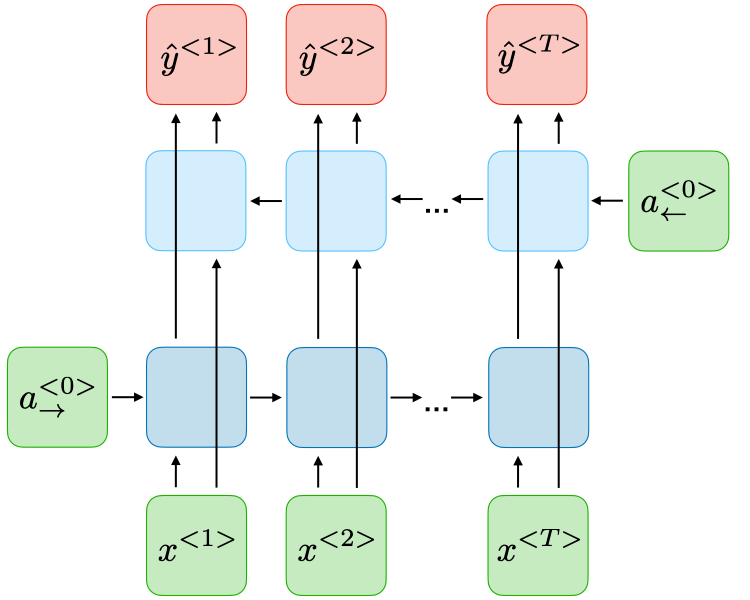


A BiRNN solves the problem by running **two RNNs in parallel**:

1. **Forward RNN (→):** Reads input from **left to right**.  
2. **Backward RNN (←):** Reads input from **right to left**.  

At each time step *t*, we **concatenate** the hidden states from both directions:
$$
h_t = [h_t^{\text{forward}}, h_t^{\text{backward}}]
$$

This combined hidden state now contains **both past and future context**.

---

## Step-by-Step Flow
1. Input sequence: $((x_1, x_2, x_3, x_4)$)  
   Example: *(Amazon, is, the, website)*  

2. **Forward RNN:**  
   - Processes $(x_1 \to x_2 \to x_3 \to x_4$).  
   - Each hidden state depends on **previous states**.

3. **Backward RNN:**  
   - Processes $(x_4 \to x_3 \to x_2 \to x_1$).  
   - Each hidden state depends on **future states**.

4. **Concatenation:**  
   At each time step \(t\):
   $$
   h_t = [h_t^{\text{forward}}, h_t^{\text{backward}}]
   $$

5. **Final Output:**  
   The combined state is passed to the output layer:
   $$
   y_t = \sigma(W \cdot h_t + b)
   $$

---

## Mathematical Formulation
For time step $(t$):

- **Forward RNN:**
$$
h_t^{\text{forward}} = f(W_f h_{t-1}^{\text{forward}} + U_f x_t + b_f)
$$

- **Backward RNN:**
$$
h_t^{\text{backward}} = f(W_b h_{t+1}^{\text{backward}} + U_b x_t + b_b)
$$

- **Output Layer:**
$$
y_t = \sigma(W \cdot [h_t^{\text{forward}}, h_t^{\text{backward}}] + b)
$$

Here:
- $(f$) = activation (tanh/ReLU)  
- $(\sigma$) = sigmoid/softmax (depending on task)  

---

## Key Intuition
- **Forward RNN** provides past context.  
- **Backward RNN** provides future context.  
- Together, BiRNN ensures **context-awareness in both directions**, making it ideal for tasks like:
  - Named Entity Recognition (NER)
  - Machine Translation
  - Speech Recognition
  - Part-of-Speech Tagging  

---


In [6]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense

# Load the IMDB dataset
num_words = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=num_words)

# Pad sequences
maxlen = 100
X_train = pad_sequences(X_train, maxlen=maxlen, padding='post', truncating='post')
X_test = pad_sequences(X_test, maxlen=maxlen, padding='post', truncating='post')

# Build the RNN model
embedding_dim = 32

model = Sequential([
    Input(shape=(maxlen,)),   # 👈 Define input shape here
    Embedding(input_dim=num_words, output_dim=embedding_dim),
    SimpleRNN(5),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model architecture
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 100, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_3 (SimpleRNN)             │ (None, 5)                   │             190 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               6 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 320,196 (1.22 MB)

 Trainable params: 320,196 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model = Sequential([
    Input(shape=(maxlen,)),   # ✅ define input here
    Embedding(input_dim=num_words, output_dim=embedding_dim),
    Bidirectional(SimpleRNN(5)),  # 5 RNN units
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model. compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy' ])

# Display model architecture
model. summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)              │ (None, 100, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 10)                  │             380 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 320,391 (1.22 MB)

 Trainable params: 320,391 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model = Sequential([
    Input(shape=(maxlen,)),   # ✅ define input once here
    Embedding(input_dim=num_words, output_dim=embedding_dim),
    Bidirectional(LSTM(5)),   # 5 LSTM units
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model. compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy' ])

# Display model architecture
model. summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)              │ (None, 100, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 10)                  │           1,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 321,531 (1.23 MB)

 Trainable params: 321,531 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

# Applications and Drawbacks of Bidirectional RNNs

## Applications
Bidirectional RNNs are powerful in scenarios where **future context is as important as past context**.  
Some common applications include:

1. **Named Entity Recognition (NER):**  
   Identifying entities like names, places, or organizations often requires looking at both past and future words.  
   - Example: *Amazon → company* vs *Amazon → river*.

2. **Part-of-Speech (POS) Tagging:**  
   Determining the correct POS tag of a word may depend on the words before and after it.  
   - Example: *"book"* → noun (*read a book*) or verb (*book a ticket*).

3. **Machine Translation:**  
   Translating text from one language to another benefits from full sentence context.  
   BiRNNs capture both directions for more accurate translations.

4. **Sentiment Analysis:**  
   The sentiment of a sentence often depends on surrounding words.  
   - Example: *"The movie was not bad"* → positive sentiment.  
   BiRNNs outperform simple RNNs in many sentiment tasks.

5. **Time-Series Forecasting:**  
   Problems like stock price prediction or weather forecasting can benefit from analyzing sequences in both directions.  
   - Often implemented as **BiLSTM** or **BiGRU**.

---

## Drawbacks
Despite their advantages, BiRNNs have limitations:

1. **Increased Complexity:**  
   - Two RNNs (forward + backward) are used.  
   - Parameters nearly **double**, leading to:
     - Higher training time.  
     - Increased risk of overfitting.  
   - Requires regularization (dropout, weight decay).

2. **Latency in Real-Time Applications:**  
   - BiRNN requires the **entire sequence** to process both directions.  
   - Not suitable for tasks like **real-time speech recognition**, where input arrives continuously.  
   - Causes **delays** (must wait until full sentence is available).

---

## When to Use
- Use BiRNNs when **entire input sequence is available** (offline NLP, translation, entity recognition).  
- Avoid them in **real-time tasks** (live speech recognition, streaming data) where low latency is critical.  

---
